# Lab 1: Understanding the Olist E-Commerce Dataset
**Prepared by:** [Pranamya Sharma]
**LinkedIn:** [https://www.linkedin.com/in/pranamya-sharma-425149321/]

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

In [2]:
DATA_DIR = Path("../data/raw") 

In [3]:
DATA_DIR.exists()

True

In [4]:
for file in DATA_DIR.glob("*.csv"):
    print(file.name)

olist_customers_dataset.csv
olist_geolocation_dataset.csv
olist_orders_dataset.csv
olist_order_items_dataset.csv
olist_order_payments_dataset.csv
olist_order_reviews_dataset.csv
olist_products_dataset.csv
olist_sellers_dataset.csv
product_category_name_translation.csv


In [5]:
customers = pd.read_csv(DATA_DIR / "olist_customers_dataset.csv")
geolocation = pd.read_csv(DATA_DIR / "olist_geolocation_dataset.csv")
order_items = pd.read_csv(DATA_DIR / "olist_order_items_dataset.csv")
payments = pd.read_csv(DATA_DIR / "olist_order_payments_dataset.csv")
reviews = pd.read_csv(DATA_DIR / "olist_order_reviews_dataset.csv")
orders = pd.read_csv(DATA_DIR / "olist_orders_dataset.csv")
products = pd.read_csv(DATA_DIR / "olist_products_dataset.csv")
sellers = pd.read_csv(DATA_DIR / "olist_sellers_dataset.csv")
category_translation = pd.read_csv(DATA_DIR / "product_category_name_translation.csv")

tables = {
    "customers": customers,
    "geolocation": geolocation,
    "order_items": order_items,
    "payments": payments,
    "reviews": reviews,
    "orders": orders,
    "products": products,
    "sellers": sellers,
    "category_translation": category_translation
}

In [6]:
for name, df in tables.items():
    print(f"{name}: {df.shape[0]} rows, {df.shape[1]} columns")

customers: 99441 rows, 5 columns
geolocation: 1000163 rows, 5 columns
order_items: 112650 rows, 7 columns
payments: 103886 rows, 5 columns
reviews: 99224 rows, 7 columns
orders: 99441 rows, 8 columns
products: 32951 rows, 9 columns
sellers: 3095 rows, 4 columns
category_translation: 71 rows, 2 columns


In [7]:
customers.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [8]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [9]:
order_items.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [10]:
products.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


In [11]:
customers.info()

<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   customer_id               99441 non-null  str  
 1   customer_unique_id        99441 non-null  str  
 2   customer_zip_code_prefix  99441 non-null  int64
 3   customer_city             99441 non-null  str  
 4   customer_state            99441 non-null  str  
dtypes: int64(1), str(4)
memory usage: 3.8 MB


In [12]:
for name, df in tables.items():
    print("\n" + "="*80)
    print(name.upper())
    print("="*80)
    print(df.info())


CUSTOMERS
<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   customer_id               99441 non-null  str  
 1   customer_unique_id        99441 non-null  str  
 2   customer_zip_code_prefix  99441 non-null  int64
 3   customer_city             99441 non-null  str  
 4   customer_state            99441 non-null  str  
dtypes: int64(1), str(4)
memory usage: 3.8 MB
None

GEOLOCATION
<class 'pandas.DataFrame'>
RangeIndex: 1000163 entries, 0 to 1000162
Data columns (total 5 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   geolocation_zip_code_prefix  1000163 non-null  int64  
 1   geolocation_lat              1000163 non-null  float64
 2   geolocation_lng              1000163 non-null  float64
 3   geolocation_city             1000163 non-null  str 

In [13]:
def summarize_table(name, df):
    return {
        "table_name": name,
        "rows": df.shape[0],
        "columns": df.shape[1],
        "missing_values": df.isnull().sum().sum(),
        "duplicate_rows": df.duplicated().sum()
    }

summary = pd.DataFrame([
    summarize_table(name, df)
    for name, df in tables.items()
])
summary

,table_name,rows,columns,missing_values,duplicate_rows
0,customers,99441,5,0,0
1,geolocation,1000163,5,0,261831
2,order_items,112650,7,0,0
3,payments,103886,5,0,0
4,reviews,99224,7,145903,0
5,orders,99441,8,4908,0
6,products,32951,9,2448,0
7,sellers,3095,4,0,0
8,category_translation,71,2,0,0


In [14]:
summary.to_csv("../reports/lab01_dataset_summary.csv", index=False)

In [15]:
def missing_value_summary(df):
    missing_count = df.isnull().sum()
    missing_percent = (missing_count / len(df)) * 100
    result = pd.DataFrame({
        "missing_count": missing_count,
        "missing_percent": missing_percent
    })
    return result[result["missing_count"] > 0].sort_values(
        by="missing_percent", ascending=False)

missing_value_summary(orders)

,missing_count,missing_percent
order_delivered_customer_date,2965,2.981668
order_delivered_carrier_date,1783,1.793023
order_approved_at,160,0.160899


In [16]:
for name, df in tables.items():
    print("\n" + "=" * 80)
    print(f"Missing Values in {name}")
    print("=" * 80)
    display(missing_value_summary(df))


Missing Values in customers


,missing_count,missing_percent



Missing Values in geolocation


,missing_count,missing_percent



Missing Values in order_items


...

,missing_count,missing_percent
product_category_name,610,1.851234
product_name_lenght,610,1.851234
product_description_lenght,610,1.851234
product_photos_qty,610,1.851234
product_weight_g,2,0.006070
product_length_cm,2,0.006070
product_height_cm,2,0.006070
product_width_cm,2,0.006070



Missing Values in sellers


,missing_count,missing_percent



Missing Values in category_translation


,missing_count,missing_percent


In [17]:
for name, df in tables.items():
    duplicate_count = df.duplicated().sum()
    print(f"{name}: {duplicate_count} duplicate rows")

customers: 0 duplicate rows
geolocation: 261831 duplicate rows
order_items: 0 duplicate rows
payments: 0 duplicate rows
reviews: 0 duplicate rows
orders: 0 duplicate rows
products: 0 duplicate rows
sellers: 0 duplicate rows
category_translation: 0 duplicate rows


### Discussion: Duplicate Records

Duplicate rows in a dataset may occur due to several reasons:
- Data entry errors during collection
- Repeated system exports (e.g., the same data pulled twice)
- Valid repeated events (e.g., a customer genuinely placing two identical orders)
- A need for further investigation before deciding how to handle them

We should not blindly delete duplicate rows without first understanding why they exist,
since removing valid repeated data could distort the dataset and mislead future analysis.

In [18]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [19]:
orders["order_status"].value_counts()

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

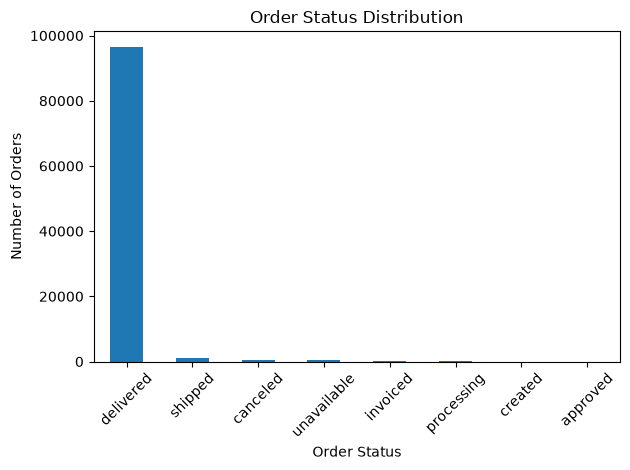

In [20]:
orders["order_status"].value_counts().plot(kind="bar")
plt.title("Order Status Distribution")
plt.xlabel("Order Status")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

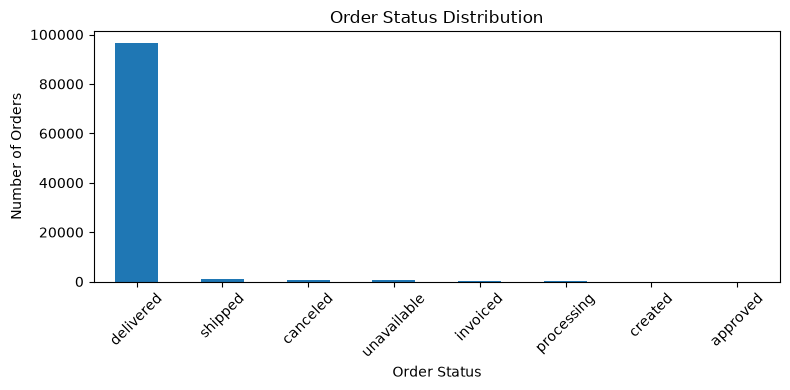

In [21]:
plt.figure(figsize=(8,4))
orders["order_status"].value_counts().plot(kind="bar")
plt.title("Order Status Distribution")
plt.xlabel("Order Status")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("../figures/lab01_order_status_distribution.png")
plt.show()

In [22]:
reviews.head()

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53


In [23]:
reviews["review_score"].value_counts().sort_index()

review_score
1    11424
2     3151
3     8179
4    19142
5    57328
Name: count, dtype: int64

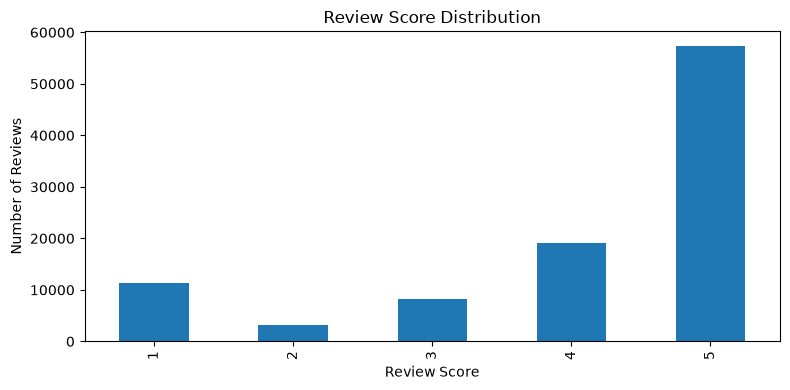

In [24]:
plt.figure(figsize=(8,4))
reviews["review_score"].value_counts().sort_index().plot(kind="bar")
plt.title("Review Score Distribution")
plt.xlabel("Review Score")
plt.ylabel("Number of Reviews")
plt.tight_layout()
plt.savefig("../figures/lab01_review_score_distribution.png")
plt.show()

In [25]:
payments.head()

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


In [26]:
payments["payment_type"].value_counts()

payment_type
credit_card    76795
boleto         19784
voucher         5775
debit_card      1529
not_defined        3
Name: count, dtype: int64

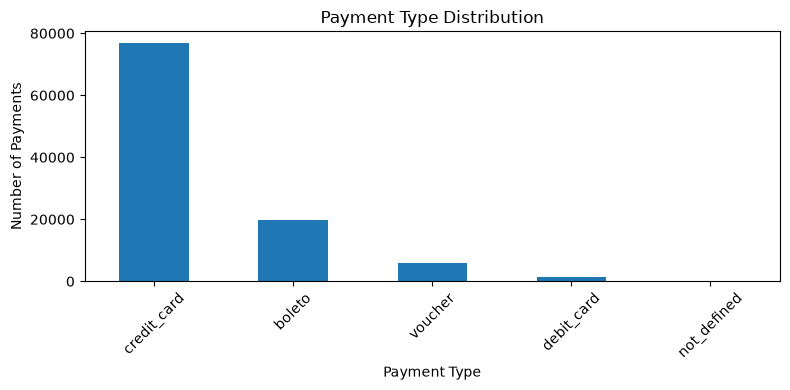

In [27]:
plt.figure(figsize=(8,4))
payments["payment_type"].value_counts().plot(kind="bar")
plt.title("Payment Type Distribution")
plt.xlabel("Payment Type")
plt.ylabel("Number of Payments")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("../figures/lab01_payment_type_distribution.png")
plt.show()

In [28]:
products.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


In [29]:
missing_value_summary(products)

,missing_count,missing_percent
product_category_name,610,1.851234
product_name_lenght,610,1.851234
product_description_lenght,610,1.851234
product_photos_qty,610,1.851234
product_weight_g,2,0.006070
product_length_cm,2,0.006070
product_height_cm,2,0.006070
product_width_cm,2,0.006070


In [30]:
products["product_category_name"].nunique()

73

In [31]:
products["product_category_name"].value_counts().head(10)

product_category_name
cama_mesa_banho           3029
esporte_lazer             2867
moveis_decoracao          2657
beleza_saude              2444
utilidades_domesticas     2335
automotivo                1900
informatica_acessorios    1639
brinquedos                1411
relogios_presentes        1329
telefonia                 1134
Name: count, dtype: int64

In [32]:
customers.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [33]:
customers["customer_state"].value_counts().head(10)

customer_state
SP    41746
RJ    12852
MG    11635
RS     5466
PR     5045
SC     3637
BA     3380
DF     2140
ES     2033
GO     2020
Name: count, dtype: int64

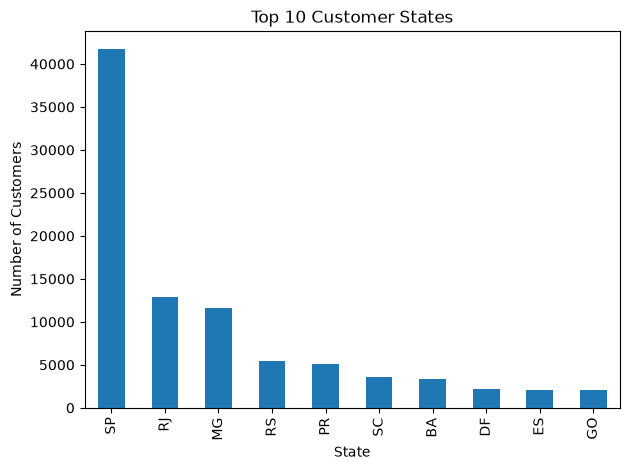

In [34]:
customers["customer_state"].value_counts().head(10).plot(kind="bar")
plt.title("Top 10 Customer States")
plt.xlabel("State")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()

In [35]:
# Q1: How many unique customers?
customers["customer_unique_id"].nunique()

96096

In [36]:
# Q2: How many orders?
orders["order_id"].nunique()

99441

In [37]:
# Q3: Most common order statuses
orders["order_status"].value_counts()

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

In [38]:
# Q4: Most common payment methods
payments["payment_type"].value_counts()

payment_type
credit_card    76795
boleto         19784
voucher         5775
debit_card      1529
not_defined        3
Name: count, dtype: int64

In [39]:
# Q5: Average review score
reviews["review_score"].mean()

np.float64(4.08642062404257)

In [40]:
# Q6: Which states have the most customers
customers["customer_state"].value_counts().head(10)

customer_state
SP    41746
RJ    12852
MG    11635
RS     5466
PR     5045
SC     3637
BA     3380
DF     2140
ES     2033
GO     2020
Name: count, dtype: int64

## Task 18: Potential Machine Learning Problems

1. **Predict Late Delivery** (Classification)
   Predict whether an order will arrive late, based on order and shipping data.
   Target: Late / Not Late

2. **Predict Review Score** (Regression/Classification)
   Predict what rating (1–5) a customer will give, based on delivery time, product type, price, etc.
   Target: review_score

3. **Predict Payment Value** (Regression)
   Predict how much a customer will pay for an order, based on product and shipping details.
   Target: payment_value

4. **Customer Segmentation** (Clustering)
   Group customers into segments (e.g., frequent buyers, one-time buyers) based on their purchase behavior.
   Target: None (unsupervised)

5. **Detect Unusual Orders** (Anomaly Detection)
   Identify orders that look unusual or suspicious compared to normal order patterns.
   Target: None (unsupervised)

## Task 19: Data Dictionary

### customers
| Column | Data Type | Description | Example Value |
|---|---|---|---|
| customer_id | String | Unique ID for each order's customer record | abc123 |
| customer_unique_id | String | Unique ID for the actual customer (can repeat across orders) | xyz789 |
| customer_city | String | City of the customer | sao paulo |
| customer_state | String | State abbreviation of the customer | SP |

### orders
| Column | Data Type | Description | Example Value |
|---|---|---|---|
| order_id | String | Unique identifier for each order | order001 |
| customer_id | String | Links to the customers table | abc123 |
| order_status | String | Current status of the order | delivered |
| order_purchase_timestamp | String (should be datetime) | When the order was placed | 2017-10-02 10:56:33 |

### order_items
| Column | Data Type | Description | Example Value |
|---|---|---|---|
| order_id | String | Links to the orders table | order001 |
| product_id | String | Links to the products table | prod001 |
| seller_id | String | Links to the sellers table | seller001 |
| price | Float | Price of the item | 89.90 |

## Reflection Question Answers
1. Why is it important to understand the dataset before building a Machine Learning model?
Ans: Because a model is only as good as the data it learns from. If we don't understand what's in the data — missing values, wrong data types, duplicate rows, or how tables connect — we could build a model based on bad or misleading information. Understanding the data first helps us clean it properly and choose the right approach before jumping into modeling.
    
2. Which table appears to be the central table in the Olist dataset? Why?
Ans: The orders table is the central table. This is because almost every other table connects back to it — order_items, payments, and reviews all use order_id to link to orders, and orders itself links to customers through customer_id. It acts like the hub that ties the whole dataset together.
    
3. What is the difference between customer_id and customer_unique_id?
Ans: customer_id is unique to each individual order — so if the same person places two orders, they get two different customer_id values. customer_unique_id stays the same for that person across all their orders — it identifies the actual human being, not just a single order.

4. Which columns appear to represent dates?
Ans: Columns like order_purchase_timestamp, order_approved_at, order_delivered_carrier_date, order_delivered_customer_date, order_estimated_delivery_date (in orders), review_creation_date and review_answer_timestamp (in reviews), and shipping_limit_date (in order_items). Note: even though these represent dates, pandas loads them as plain text (object type) by default — they'd need to be converted using pd.to_datetime() before doing date-based analysis.

5. Which columns appear to represent categorical variables?
Ans: Columns like order_status (in orders), payment_type (in payments), product_category_name (in products), and customer_state/customer_city (in customers) — these all represent a fixed set of categories/labels rather than continuous numbers.

6. Which columns contain missing values?
Ans: Based on the missing value analysis (Task 10), columns like order_approved_at, order_delivered_carrier_date, and order_delivered_customer_date (in orders) often have missing values — likely because some orders were never completed or delivered. The products table also has missing values in columns like product_category_name and physical dimension fields. (Fill in your exact numbers from your own Task 10 output here, since these can vary slightly.)

7. Which tables can be joined using order_id?
Ans: orders, order_items, payments, and reviews — all four contain the order_id column and can be linked together through it.

8. Which tables can be joined using product_id?
Ans: order_items and products — both contain product_id, allowing us to look up full product details for each item in an order.

9. What are three potential Machine Learning problems that can be created from this dataset?
Ans: (1) Predicting whether an order will be delivered late (classification), (2) predicting the review score a customer will give (regression/classification), and (3) segmenting customers into groups based on purchase behavior (clustering).

10. What ethical concerns may arise when using customer data for ML?
Ans: Customer data includes personal details like location and purchase history, so there's a risk of privacy violation if this data is misused or exposed. There's also a risk of bias — for example, a model might unfairly treat customers from certain regions differently based on patterns in the data. It's important to anonymize sensitive information and be transparent about how customer data is used.